# Анализ приоритизации обращений

Минимальный baseline для задачи.  
Он обучает простую модель только на готовых табличных признаках из `train.csv` / `test.csv` и создает `submission.csv`.

`events.csv` можно использовать для улучшения решения, но в baseline признаки из событий не строятся.

In [858]:
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings

In [859]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [860]:
# Пути к данным.
ROOT = Path(".")
DATA_DIR = ROOT / "data"

TARGET = "target"

# Эти колонки не используем как признаки модели.
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

RANDOM_STATE = 42

## Загрузка данных

Загружаем обучающую выборку, тестовую выборку и события.  
В baseline модель использует только `train.csv` и `test.csv`.

In [861]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)

train: (13694, 119)
test: (4306, 118)
events: (254705, 7)


In [862]:
# events.csv не используется в baseline, но его можно исследовать для улучшения решения.
events.head()

,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02


## Разведывательный анализ

### Анализ данных в train

In [863]:
len(train[train['target'] == 1]) / len(train)

0.20746312253541696

In [864]:
# train.describe()

In [865]:
# train.isna().sum()

In [866]:
# events.isna().sum()

In [867]:
# test.isna().sum()

In [868]:
train['region'].value_counts(dropna=False)

region
east       2796
west       2770
central    2725
north      2710
south      2693
Name: count, dtype: int64

In [869]:
train['call_center'].value_counts(dropna=False)

call_center
external    7882
voxys       5812
Name: count, dtype: int64

In [870]:
train['car_segment'].value_counts(dropna=False)

car_segment
standard      5780
budget        4713
premium       1909
commercial    1292
Name: count, dtype: int64

In [871]:
train['lead_source'].value_counts(dropna=False)

lead_source
Model    5688
CRM      4839
Perf     3167
Name: count, dtype: int64

In [872]:
def find_monotonicity_violations(df):
    """
    Возвращает строки df, где нарушается неубывание значений
    в столбцах (item_views_1d <= item_views_3d <= ...).
    Пары, где хотя бы одно значение NaN, игнорируются.
    """

    cols = [
        "item_views_1d", "item_views_3d", "item_views_7d",
        "item_views_14d", "item_views_30d", "item_views_90d"
    ]

    violation = pd.Series(False, index=df.index)

    for prev_col, curr_col in zip(cols[:-1], cols[1:]):
        prev = df[prev_col]
        curr = df[curr_col]

        both_valid = prev.notna() & curr.notna()

        violation = violation | (both_valid & (prev > curr))

    return df.loc[violation]

print(len(find_monotonicity_violations(train)) / len(train))
print(len(find_monotonicity_violations(test)) / len(test))

0.23375200817876443
0.24291686019507663


### Проверка на выбросы

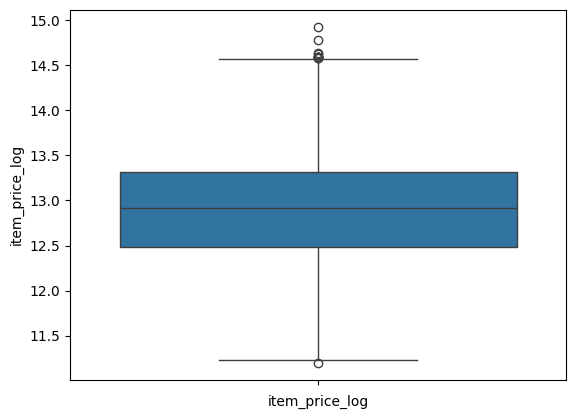

Число и доля выбросов сверху: 11, 0.0008032715057689499
Число и доля выбросов снизу: 1, 7.30246823426318e-05


In [873]:
def draw_boxplot(data=train, feature='item_price_log'):
    sns.boxplot(data[feature])
    plt.xlabel(feature)
    plt.show()

    Q1 = np.percentile(data[feature], 25)
    Q3 = np.percentile(data[feature], 75)
    IQR = Q3 - Q1

    print(f'Число и доля выбросов сверху: {len(data[data[feature] > (Q3 + 1.5 * IQR)])}, {len(data[data[feature] > (Q3 + 1.5 * IQR)]) / len(data)}')
    print(f'Число и доля выбросов снизу: {len(data[data[feature] < (Q1 - 1.5 * IQR)])}, {len(data[data[feature] < (Q1 - 1.5 * IQR)]) / len(data)}')

draw_boxplot(train, 'item_price_log')

In [874]:
# draw_boxplot(train, 'mileage_km_log')

In [875]:
# draw_boxplot(train, 'car_age_years')

In [876]:
# draw_boxplot(train, 'seller_inventory_count')

### Анализ данных в events

{1: 45, 2: 109, 3: 186, 4: 339, 5: 556, 6: 731, 7: 960, 8: 1022, 9: 1083, 10: 1180, 11: 1099, 12: 1049, 13: 980, 14: 955, 15: 862, 16: 790, 17: 768, 18: 645, 19: 587, 20: 505, 21: 439, 22: 416, 23: 349, 24: 780, 25: 484, 26: 375, 27: 277, 28: 174, 29: 100, 30: 74, 31: 36, 32: 12, 33: 13, 34: 5, 35: 3}


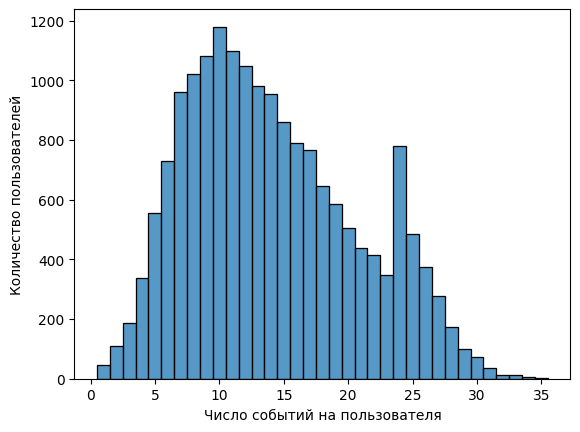

In [877]:
# Сколько событий из events приходится на один user_id из events?

counts = events.groupby('user_id').size()
print(counts.value_counts().sort_index().to_dict())
# print(counts)
sns.histplot(counts, discrete=True)
plt.xlabel('Число событий на пользователя')
plt.ylabel('Количество пользователей')
plt.show()

In [878]:
# Какие типы событий есть в event_type?
# plt.figure(figsize=(12, 6))
# print(events.groupby('event_type').size().value_counts().sort_index().to_dict())
# sns.countplot(data=events, x='event_type', order=events['event_type'].value_counts().index)
# plt.title('Распределение событий по типам', size=14)
# plt.xlabel('Тип события')
# plt.ylabel('Количество событий')
# plt.xticks(rotation=45)
# plt.show()

In [879]:
# У какого процента user_id и lead_id из train.csv есть хотя бы одна запись в events.csv?
def get_overlap_percentage(df, feature):
    event_set = set(events[feature].dropna().unique())
    df_set = set(df[feature].dropna().unique())
    matched_users = df_set.intersection(event_set)
    
    print(len(matched_users))
    return (len(matched_users) / len(df_set)) * 100

print(f"Процент user_id из TRAIN, которые есть в events: {get_overlap_percentage(train, 'user_id'):.3f}%")
print(f"Процент user_id из TEST, которые есть в events:  {get_overlap_percentage(test, 'user_id'):.3f}%\n")

print(f"Процент lead_id из TRAIN, которые есть в events: {get_overlap_percentage(train, 'lead_id'):.3f}%")
print(f"Процент lead_id из TEST, которые есть в events:  {get_overlap_percentage(test, 'lead_id'):.3f}%\n")

13685
Процент user_id из TRAIN, которые есть в events: 99.934%
4303
Процент user_id из TEST, которые есть в events:  99.930%

13685
Процент lead_id из TRAIN, которые есть в events: 99.934%
4303
Процент lead_id из TEST, которые есть в events:  99.930%



In [880]:
# Посчитаем разницу между event_ts и assignment_ts

def calc_time_diff(train_df, events_df):    
    train = train_df[['lead_id', 'assignment_ts']].copy()
    events = events_df[['lead_id', 'event_ts']].copy()
    
    train['assignment_ts'] = pd.to_datetime(train['assignment_ts'])
    events['event_ts'] = pd.to_datetime(events['event_ts'])
    
    merged_df = pd.merge(train, events, on='lead_id', how='inner')
    
    merged_df['time_diff'] = merged_df['assignment_ts'] - merged_df['event_ts']
    merged_df['time_diff'] = merged_df['time_diff'].dt.total_seconds() / 3600
    
    return merged_df[merged_df['event_ts'] < merged_df['assignment_ts']] # чтобы не было target leakage

# plt.figure(figsize=(12, 6))
# sns.histplot(data=calc_time_diff(train, events), discrete=True)
# plt.title('Разница между датой назначения и датой события', size=14)
# plt.show()

In [881]:
# Посчитаем среднее количество событий каждого типа для target=0 и target=1.

def calculate_avg_events_per_target(train_df, events_df):
    event_counts = events_df.groupby(['lead_id', 'event_type']).size().unstack(fill_value=0)
    
    merged_df = train_df.merge(event_counts, on='lead_id', how='inner')

    event_type_cols = event_counts.columns
    merged_df[event_type_cols] = merged_df[event_type_cols].fillna(0)
    
    avg_events = merged_df.groupby('target')[event_type_cols].mean()
    
    return avg_events

calculate_avg_events_per_target(train, events)

,call_click,chat_open,favorite,item_view,search
target,,,,,
0,1.024899,1.191534,1.249816,6.435633,3.312523
1,2.080957,2.338613,2.523407,8.253080,3.854981


In [882]:
# Совпадает ли цена у одного и того же обращения в train и events?

def is_price_equal(train, events):

    events = events.rename(columns={'item_price_log': 'event_price'})
    train = train.rename(columns={'item_price_log': 'train_price'})

    merged = pd.merge(train, events, on='lead_id', how='left')

    merged['is_price_match'] = np.isclose(merged['event_price'], merged['train_price'], equal_nan=True)

    total_leads = len(merged)
    matched_leads = merged['is_price_match'].sum()
    missing_events = merged['event_price'].isna().sum()

    print(f"Всего лидов в train: {total_leads}")
    print(f"Лидов без событий в events: {missing_events}")
    print(f"Совпадает цена: {matched_leads} ({matched_leads / total_leads * 100:.2f}%)")
    print(f"Не совпадает цена: {total_leads - matched_leads - missing_events}")
is_price_equal(train, events) # нет!

Всего лидов в train: 197430
Лидов без событий в events: 9
Совпадает цена: 162 (0.08%)
Не совпадает цена: 197259


In [883]:
# draw_boxplot(events, 'src_slot')

In [884]:
# sns.histplot(events['src_slot'], discrete=True)
# plt.xlabel('src_slot')
# plt.ylabel('Количество')
# plt.show()

In [885]:
# plt.figure(figsize=(12, 6))
# print(events['ctx_seq'].value_counts().sort_index().to_dict())
# sns.histplot(data=events['ctx_seq'], discrete=True)
# plt.title('Распределение ctx_seq', size=14)
# plt.show()

### Анализ target и временной структуры

target mean: 0.20746


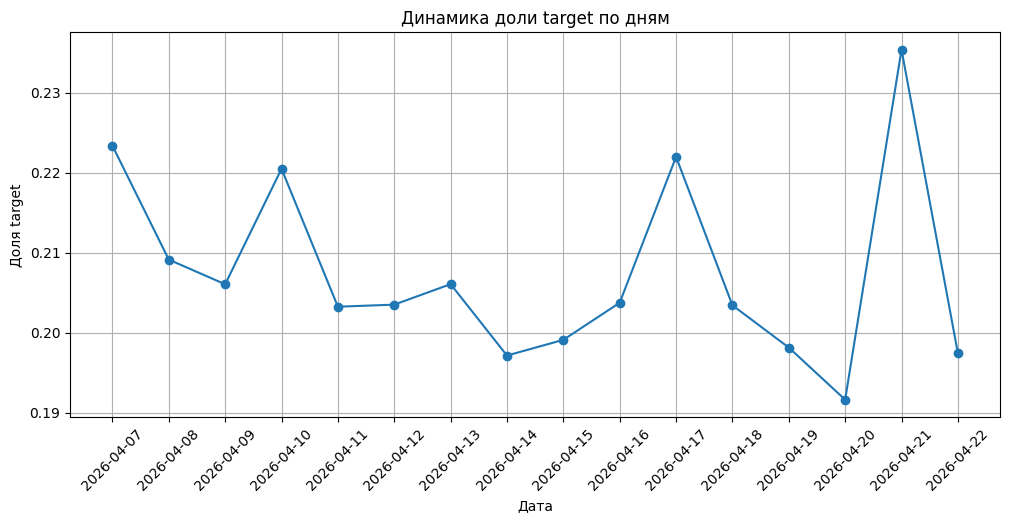

In [886]:
# Доля target глобально и по дням
print("target mean:", f'{train[TARGET].mean():.5f}')

counts = train.groupby('assignment_date')[TARGET].mean()
plt.figure(figsize=(12, 5))
plt.plot(counts.index, counts.values, marker='o', linestyle='-')
plt.xlabel('Дата')
plt.ylabel('Доля target')
plt.title('Динамика доли target по дням')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [887]:
# Распределение обращений по часам и дням недели
def plot_requests(data, mode, data_name, target):
    plt.figure(figsize=(12, 5))

    if mode == 'hour':
        plt.xlabel('Час дня')
        plt.title(f'Динамика в зависимости от часа дня: {data_name}')
    elif mode == 'weekday':
        plt.xlabel('День недели')
        plt.title(f'Динамика в зависимости от дня недели: {data_name}')
    else:
        raise AttributeError('График строится либо по часам (hour), либо по дням недели (day)')

    if target:
        plt.ylabel('Доля target')
        counts = data.groupby(f'assignment_{mode}')[TARGET].mean()
           
    else:
        plt.ylabel('Число обращений')
        counts = data.groupby(f'assignment_{mode}').size()
        
    print(counts)
    plt.plot(counts.index, counts.values, marker='o', linestyle='-')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# plot_requests(train, 'weekday', 'train', False)
# plot_requests(train, 'weekday', 'train', True)
# plot_requests(test, 'weekday', 'test', False)

# plot_requests(train, 'hour', 'train', False)
# plot_requests(train, 'hour', 'train', True)
# plot_requests(test, 'hour', 'test', False)

In [888]:
# Сравнение временных интервалов
print('Временной интервал train', train['assignment_date'].min(), train['assignment_date'].max())
print('Временной интервал test', test['assignment_date'].min(), test['assignment_date'].max())

Временной интервал train 2026-04-07 2026-04-22
Временной интервал test 2026-04-23 2026-04-27


## Добавление новых признаков

In [889]:
def build_anomaly_features(df: pd.DataFrame) -> pd.DataFrame:
    out_df = pd.DataFrame(index=df.index)
    windows = ['1d', '3d', '7d', '14d', '30d', '90d']
    feature_groups = ['item_views', 'item_favorites', 'detail_expands', 'photo_swipes', 
                      'seller_page_views', 'search_views', 'query_refinements', 'similar_item_clicks', 
                      'saved_search_matches', 'user_contacts', 'chat_opens', 'call_clicks', 
                      'leadgen_prev_assigned', 'leadgen_prev_answered', 'leadgen_prev_positive', 'active_days_auto'] 
    
    anomaly_matrix = []
    for group in feature_groups:
        for i in range(len(windows) - 1):
            w_curr = f"{group}_{windows[i]}"
            w_next = f"{group}_{windows[i+1]}"
            if w_curr in df.columns and w_next in df.columns:
                violation = df[w_curr] > df[w_next]
                anomaly_matrix.append(violation)
    
    if anomaly_matrix:
        anomaly_df = pd.concat(anomaly_matrix, axis=1)
        out_df['is_anomaly_windows'] = anomaly_df.any(axis=1).astype(int)
        out_df['anomaly_windows_count'] = anomaly_df.sum(axis=1)
    else:
        out_df['is_anomaly_windows'] = 0
        out_df['anomaly_windows_count'] = 0
        
    return out_df

In [890]:
def build_events_features(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    train_ts = main_df[['lead_id', 'assignment_ts', 'item_price_log']].copy()
    train_ts['assignment_ts'] = pd.to_datetime(train_ts['assignment_ts'])
    
    events = events_df.copy()
    events['event_ts'] = pd.to_datetime(events['event_ts'])

    merged = pd.merge(events, train_ts, on='lead_id', how='inner', suffixes=('_event', '_main'))
    merged = merged[merged['event_ts'] < merged['assignment_ts']].copy()
    merged['time_diff_hours'] = (merged['assignment_ts'] - merged['event_ts']).dt.total_seconds() / 3600.0  
    merged = merged.sort_values(by=['lead_id', 'event_ts'])

    extracted_features = pd.DataFrame(index=main_df['lead_id'].drop_duplicates())
    
    if merged.empty:
        return extracted_features.reset_index()
        
    extracted_features['min_time_lag'] = merged.groupby('lead_id')['time_diff_hours'].min()
    extracted_features['acted_in_last_hour'] = (extracted_features['min_time_lag'] <= 1.0).astype(int)
    
    for etype in ['call_click', 'chat_open', 'favorite']:
        mask = merged['event_type'] == etype
        extracted_features[f'time_since_last_{etype}'] = merged[mask].groupby('lead_id')['time_diff_hours'].min()
    
    merged['is_1h'] = (merged['time_diff_hours'] <= 1.0).astype(int)
    merged['is_6h'] = (merged['time_diff_hours'] <= 6.0).astype(int)
    
    velocity_stats = merged.groupby('lead_id').agg(
        events_count_1h=('is_1h', 'sum'),
        events_count_6h=('is_6h', 'sum')
    )
    extracted_features = extracted_features.join(velocity_stats)
    
    merged['decay_weight'] = np.exp(-0.346 * merged['time_diff_hours'])
    extracted_features['time_decayed_score'] = merged.groupby('lead_id')['decay_weight'].sum()
    
    total_counts = merged.groupby('lead_id').size()
    extracted_features['total_events_count'] = total_counts
    
    if 'item_price_log_event' in merged.columns:
        extracted_features['nunique_prices'] = merged.groupby('lead_id')['item_price_log_event'].nunique()
    if 'ctx_seq' in merged.columns:
        extracted_features['nunique_contexts'] = merged.groupby('lead_id')['ctx_seq'].nunique()

    event_type_counts = merged.groupby(['lead_id', 'event_type']).size().unstack(fill_value=0)
    for col in ['call_click', 'chat_open', 'favorite', 'item_view', 'search']:
        if col in event_type_counts.columns:
            extracted_features[f'{col}_count'] = event_type_counts[col]
            extracted_features[f'{col}_ratio'] = event_type_counts[col] / total_counts
        else:
            extracted_features[f'{col}_count'] = 0
            extracted_features[f'{col}_ratio'] = 0.0
            
    extracted_features['search_to_view_ratio'] = (
        extracted_features['search_count'] / (extracted_features['item_view_count'] + 1e-5)
    )
    
    if 'src_slot' in merged.columns:
        merged['src_slot'] = pd.to_numeric(merged['src_slot'], errors='coerce')
        src_stats = merged.groupby('lead_id')['src_slot'].agg(['mean', 'max', 'last'])
        extracted_features['src_slot_mean'] = src_stats['mean']
        extracted_features['src_slot_max'] = src_stats['max']
        extracted_features['src_slot_last'] = src_stats['last']
        
    if 'ctx_seq' in merged.columns:
        top_contexts = ['c01', 'c02', 'c04', 'c06', 'c08']
        ctx_counts = merged.groupby(['lead_id', 'ctx_seq']).size().unstack(fill_value=0)
        for ctx in top_contexts:
            extracted_features[f'ctx_{ctx}_count'] = ctx_counts[ctx] if ctx in ctx_counts.columns else 0

    if 'item_price_log_event' in merged.columns and 'item_price_log_main' in merged.columns:
        price_stats = merged.groupby('lead_id').agg(
            first_event_price=('item_price_log_event', 'first'),
            mean_event_price=('item_price_log_event', 'mean'),
            last_event_price=('item_price_log_event', 'last'),
            main_price=('item_price_log_main', 'last')
        )
        extracted_features['price_mismatch_mean_delta'] = price_stats['main_price'] - price_stats['mean_event_price']
        extracted_features['price_mismatch_last_delta'] = price_stats['main_price'] - price_stats['last_event_price']
        extracted_features['price_trend_last_minus_first'] = price_stats['last_event_price'] - price_stats['first_event_price']

    return extracted_features.reset_index()

In [891]:
def build_funnel_and_session_features(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    train_ts = main_df[['lead_id', 'assignment_ts']].copy()
    train_ts['assignment_ts'] = pd.to_datetime(train_ts['assignment_ts'])
    
    events = events_df.copy()
    events['event_ts'] = pd.to_datetime(events['event_ts'])

    merged = pd.merge(events, train_ts, on='lead_id', how='inner')
    merged = merged[merged['event_ts'] < merged['assignment_ts']].copy()
    merged = merged.sort_values(by=['lead_id', 'event_ts'])
    
    extracted = pd.DataFrame(index=main_df['lead_id'].drop_duplicates())
    if merged.empty:
        return extracted.reset_index()

    funnel_weights = {
        'item_view': 1, 'search': 1, 'similar_item_clicks': 1,
        'detail_expands': 2, 'photo_swipes': 2, 'seller_page_views': 2,
        'favorite': 3, 'saved_search_matches': 3,
        'chat_open': 4, 'user_contacts': 4,
        'call_click': 5
    }
    merged['funnel_weight'] = merged['event_type'].map(funnel_weights).fillna(0)
    
    funnel_stats = merged.groupby('lead_id').agg(
        max_funnel_depth=('funnel_weight', 'max'),
        avg_funnel_depth=('funnel_weight', 'mean')
    )
    extracted = extracted.join(funnel_stats)
    extracted['reached_hot_funnel'] = (extracted['max_funnel_depth'] >= 4).astype(int)

    merged['time_diff_mins'] = merged.groupby('lead_id')['event_ts'].diff().dt.total_seconds() / 60.0
    merged['is_new_session'] = (merged['time_diff_mins'] > 30).fillna(1).astype(int)
    merged['session_id'] = merged.groupby('lead_id')['is_new_session'].cumsum()
    
    session_stats = merged.groupby('lead_id').agg(
        total_sessions=('session_id', 'nunique'),
        avg_events_per_session=('session_id', 'count') 
    )
    session_stats['avg_events_per_session'] = merged.groupby('lead_id').size() / session_stats['total_sessions']
    
    extracted = extracted.join(session_stats)
    extracted['is_one_time_user'] = ((extracted['total_sessions'] == 1) & (extracted['avg_events_per_session'] <= 3)).astype(int)

    return extracted.reset_index()

In [892]:
def build_user_level_features(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Глобальная история действий конкретного user_id до момента назначения текущего обращения (lead_id).
    """
    if 'user_id' not in main_df.columns or 'user_id' not in events_df.columns:
        return pd.DataFrame(index=main_df['lead_id']).reset_index()
        
    train_ts = main_df[['lead_id', 'user_id', 'assignment_ts']].copy()
    train_ts['assignment_ts'] = pd.to_datetime(train_ts['assignment_ts'])
    
    events = events_df[['user_id', 'event_ts', 'event_type', 'lead_id']].rename(columns={'lead_id': 'event_lead_id'})
    events['event_ts'] = pd.to_datetime(events['event_ts'])

    merged = pd.merge(train_ts, events, on='user_id', how='inner')
    # Жесткая защита от ликов: только события до assignment_ts текущего lead_id
    merged = merged[merged['event_ts'] < merged['assignment_ts']]
    
    extracted = pd.DataFrame(index=main_df['lead_id'].drop_duplicates())
    if merged.empty:
        return extracted.reset_index()

    merged['is_hot_action'] = merged['event_type'].isin(['chat_open', 'call_click', 'user_contacts', 'favorite']).astype(int)
    
    user_stats = merged.groupby('lead_id').agg(
        user_hist_total_events=('event_ts', 'count'),
        user_hist_distinct_leads=('event_lead_id', 'nunique'),
        user_hist_hot_actions=('is_hot_action', 'sum'),
        user_hist_first_event_ts=('event_ts', 'min'),
        user_hist_last_event_ts=('event_ts', 'max')
    )
    
    user_stats = user_stats.join(train_ts.set_index('lead_id')['assignment_ts'])
    
    user_stats['user_hist_tenure_days'] = (user_stats['assignment_ts'] - user_stats['user_hist_first_event_ts']).dt.total_seconds() / 86400.0
    user_stats['user_hist_hours_since_last_event'] = (user_stats['assignment_ts'] - user_stats['user_hist_last_event_ts']).dt.total_seconds() / 3600.0
    user_stats['user_hist_hot_action_rate'] = user_stats['user_hist_hot_actions'] / user_stats['user_hist_total_events']
    
    user_stats = user_stats.drop(columns=['assignment_ts', 'user_hist_first_event_ts', 'user_hist_last_event_ts'])
    
    extracted = extracted.join(user_stats).fillna(0)
    return extracted.reset_index()

In [893]:
def build_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    out_df = pd.DataFrame(index=df.index)
    
    if 'item_price_log' in df.columns and 'events_count_1h' in df.columns:
        out_df['price_x_recent_activity'] = df['item_price_log'] * df['events_count_1h'].fillna(0)
        
    if 'user_account_age_days' in df.columns and 'max_funnel_depth' in df.columns:
        out_df['age_x_funnel_depth'] = df['user_account_age_days'].fillna(0) * df['max_funnel_depth'].fillna(0)
        
    if 'price_mismatch_last_delta' in df.columns and 'reached_hot_funnel' in df.columns:
        out_df['abs_price_mismatch_for_hot'] = df['price_mismatch_last_delta'].abs() * df['reached_hot_funnel']

    if 'total_sessions' in df.columns and 'min_time_lag' in df.columns:
        out_df['sessions_per_hour'] = df['total_sessions'] / (df['min_time_lag'].clip(lower=0.1))

    # Циклическое кодирование времени назначения (critical boost для древовидных алгоритмов)
    if 'assignment_ts' in df.columns:
        ts = pd.to_datetime(df['assignment_ts'])
        out_df['assign_hour_sin'] = np.sin(2 * np.pi * ts.dt.hour / 24.0)
        out_df['assign_hour_cos'] = np.cos(2 * np.pi * ts.dt.hour / 24.0)
        out_df['assign_dow_sin'] = np.sin(2 * np.pi * ts.dt.dayofweek / 7.0)
        out_df['assign_dow_cos'] = np.cos(2 * np.pi * ts.dt.dayofweek / 7.0)

    # Плотность исторических событий (активность)
    if 'user_hist_total_events' in df.columns and 'user_account_age_days' in df.columns:
        out_df['user_event_density'] = df['user_hist_total_events'] / (df['user_account_age_days'].clip(lower=1.0))

    return out_df

In [894]:
def build_platform_density_features(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Считает суммарную нагрузку (активность) всей платформы за час, 
    предшествующий текущему назначению.
    """
    events_dt = pd.to_datetime(events_df['event_ts'])
    # Считаем количество абсолютно всех событий платформы по часовым слотам
    events_hourly = events_dt.dt.floor('h').value_counts().rename('global_events_hourly_count').to_frame()
    
    # Для каждого лида определяем предыдущий полный час (чтобы не заглядывать в будущее)
    main_ts = pd.to_datetime(main_df['assignment_ts'])
    lookup_hour = main_ts.dt.floor('h') - pd.Timedelta(hours=1)
    
    out_df = pd.DataFrame(index=main_df.index)
    out_df['lookup_hour'] = lookup_hour
    
    # Джойним глобальную статистику
    out_df = out_df.join(events_hourly, on='lookup_hour', how='left')
    out_df['global_events_hourly_count'] = out_df['global_events_hourly_count'].fillna(0)
    
    return out_df[['global_events_hourly_count']]

In [895]:
def pipeline_feature_engineering(main_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
    first_block = build_anomaly_features(main_df)    
    second_block = build_events_features(main_df, events_df)
    third_block = build_funnel_and_session_features(main_df, events_df)   
    fourth_block_user = build_user_level_features(main_df, events_df)
    global_density_block = build_platform_density_features(main_df, events_df)

    full_df = main_df.copy()
    full_df = pd.concat([full_df, first_block, global_density_block], axis=1)
    
    for block in [second_block, third_block, fourth_block_user]:
        if 'lead_id' in block.columns:
            full_df = pd.merge(full_df, block, on='lead_id', how='left')
            
    fifth_block_inter = build_interaction_features(full_df)
    full_df = pd.concat([full_df, fifth_block_inter], axis=1)
        
    return full_df.copy()

In [896]:
train = pipeline_feature_engineering(train, events)
test = pipeline_feature_engineering(test, events)

### Анализ корреляции

Также была проанализирована матрица корреляций "всего со всем", но оттуда не удалось взять много информации: коррелируют между собой агрегаты; цена, пробег и возраст машины

In [897]:
# train_numeric = train.select_dtypes(include='number')

# corr_with_target = train_numeric.corrwith(train_numeric['target']).drop('target')

# corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

# plt.figure(figsize=(5, 30))
# sns.barplot(
#     x=corr_sorted.values, 
#     y=corr_sorted.index, 
#     palette='coolwarm'
# )
# plt.axvline(0, color='black', linestyle='--', linewidth=1)
# plt.title('Корреляция признаков с целевой переменной (target)', fontsize=14, pad=15)
# plt.xlabel('Коэффициент корреляции Пирсона', fontsize=12)
# plt.ylabel('Признаки', fontsize=12)
# plt.xlim(-1, 1)
# plt.tight_layout()
# plt.show()

## Выбор признаков

Исключаем `lead_id`, `user_id`, timestamps и target.  
Остальные колонки используем как стартовый набор признаков.

In [898]:
feature_cols = [c for c in train.columns if c not in NON_FEATURE_COLUMNS]
cat_cols = list(train[feature_cols].select_dtypes(include=["object", "category"]).columns)
num_cols = [c for c in feature_cols if c not in cat_cols]

print("numeric:", len(num_cols))
print("categorical:", len(cat_cols))
print("total features:", len(feature_cols))

numeric: 162
categorical: 7
total features: 169


## Валидация

Так как тестовая выборка находится позже train по времени, лучше валидироваться на последних датах train.  
Это ближе к реальному сценарию, чем случайный split.

In [899]:
def make_validation_split(train_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Делит train по времени: ранние даты в обучение, поздние даты в валидацию."""
    if "assignment_date" in train_df.columns:
        dates = pd.to_datetime(train_df["assignment_date"]).dt.date
        ordered_dates = sorted(dates.unique())
        cutoff = ordered_dates[int(len(ordered_dates) * 0.8)]

        train_part = train_df[dates < cutoff]
        valid_part = train_df[dates >= cutoff]
        return train_part, valid_part

    # Fallback, если даты нет.
    return train_test_split(
        train_df,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=train_df[TARGET],
    )


train_part, valid_part = make_validation_split(train)

# Удалим выбросы из тех признаков, где необходимо

def remove_outliers(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    filtered_df = df.copy()
    for column_name in columns:
        Q1 = filtered_df[column_name].quantile(0.25)
        Q3 = filtered_df[column_name].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        filtered_df = filtered_df[(filtered_df[column_name] >= lower_bound) & (filtered_df[column_name] <= upper_bound)]
    return filtered_df

# train_part = remove_outliers(train_part, ['car_age_years']) - лучше не убирать

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)

train_part: (10272, 174)
valid_part: (3422, 174)


## Модель

Используем простую Logistic Regression:

- числовые признаки: заполнение пропусков медианой и scaling;
- категориальные признаки: заполнение самым частым значением и one-hot encoding;
- `class_weight="balanced"` из-за дисбаланса классов.

In [900]:
class PipelineFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols, cat_cols, smoothing=10):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.smoothing = smoothing
        self.medians_ = {}
        self.target_mappings_ = {}
        
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.num_cols + self.cat_cols)
        
        # Сохраняем медианы для числовых колонок
        for col in self.num_cols:
            if col in X_df.columns:
                self.medians_[col] = X_df[col].median()
                
        # Вычисляем Target Encoding (только если передан y — то есть строго на тренировочной части)
        if y is not None:
            y_series = pd.Series(y, index=X_df.index)
            global_mean = y_series.mean()
            for col in self.cat_cols:
                if col in X_df.columns:
                    stats = y_series.groupby(X_df[col]).agg(['count', 'mean'])
                    # Формула сглаживания (Smoothing) для защиты от оверфиттинга на редких категориях
                    smoothed_vals = (stats['count'] * stats['mean'] + self.smoothing * global_mean) / (stats['count'] + self.smoothing)
                    self.target_mappings_[col] = smoothed_vals.to_dict()
                    self.target_mappings_[col]['global_mean'] = global_mean
        return self
        
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.num_cols + self.cat_cols)
        
        # 1. Числовые пропуски
        for col in self.num_cols:
            if col in X_df.columns:
                X_df[col] = X_df[col].fillna(self.medians_.get(col, 0))
        
        # 2. Базовый Feature Engineering
        if 'item_views_1d' in X_df.columns and 'item_views_7d' in X_df.columns:
            X_df['views_ratio_1d_7d'] = X_df['item_views_1d'] / (X_df['item_views_7d'] + 1)
        if 'item_favorites_1d' in X_df.columns and 'item_favorites_7d' in X_df.columns:
            X_df['fav_ratio_1d_7d'] = X_df['item_favorites_1d'] / (X_df['item_favorites_7d'] + 1)
        if 'car_age_years' in X_df.columns and 'mileage_km_log' in X_df.columns:
            X_df['mileage_per_year'] = X_df['mileage_km_log'] / (X_df['car_age_years'] + 1)
            
        # 3. Применяем Target Encoding и переводим оригинальные фичи в 'category'
        for col in self.cat_cols:
            if col in X_df.columns:
                mapping = self.target_mappings_.get(col, {})
                g_mean = mapping.get('global_mean', 0.0)
                
                X_df[col] = X_df[col].fillna("missing_value").astype(str)
                # Создаем новую числовую фичу на основе таргета
                X_df[f'{col}_target_enc'] = X_df[col].map(mapping).fillna(g_mean)
                # Оригинальную колонку отдаем бустингам как категориальную
                X_df[col] = X_df[col].astype("category")
                
        return X_df

In [901]:
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [902]:
def calculate_daily_ap(df: pd.DataFrame, preds: np.ndarray, target_col=TARGET, date_col='assignment_date') -> float:
    df_eval = df[[target_col, date_col]].copy()
    df_eval['preds'] = preds
    
    daily_aps = []
    for date, group in df_eval.groupby(date_col):
        # Метрику можно посчитать только если в сутках есть и нули, и единицы
        if group[target_col].nunique() > 1:
            daily_aps.append(average_precision_score(group[target_col], group['preds']))
            
    return np.mean(daily_aps) if daily_aps else 0.0

In [903]:
# 1. Подготовка и трансформация данных (передаем y_train для Target Encoding)
fe_transformer = PipelineFeatureEngineer(num_cols=num_cols, cat_cols=cat_cols)

y_train = train_part[TARGET].values
X_train_processed = fe_transformer.fit_transform(train_part[feature_cols], y=y_train)

y_valid = valid_part[TARGET].values
X_valid_processed = fe_transformer.transform(valid_part[feature_cols])

X_test_processed = fe_transformer.transform(test[feature_cols])

# Динамически обновляем список фичей (так как добавились колонки target_enc)
current_features = list(X_train_processed.columns)

In [904]:
# 2. Оптимизация гиперпараметров для КАЖДОЙ модели отдельно
models_to_tune = ["catboost", "lightgbm", "xgboost"]
best_params_dict = {}

print("Запуск раздельной оптимизации Optuna под метрику Daily AP...")

for m_type in models_to_tune:
    print(f"\n--- Тюнинг {m_type} ---")
    
    def objective(trial):
        if m_type == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 400, 1000),
                "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08),
                "depth": trial.suggest_int("depth", 4, 7),
                "eval_metric": "PRAUC",
                "random_seed": RANDOM_STATE,
                "cat_features": cat_cols,
                "verbose": 0
            }
            clf = CatBoostClassifier(**params)
            
        elif m_type == "lightgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 400, 1000),
                "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08),
                "max_depth": trial.suggest_int("max_depth", 4, 7),
                "num_leaves": trial.suggest_int("num_leaves", 15, 63),
                "random_state": RANDOM_STATE,
                "verbose": -1,
                "n_jobs": -1
            }
            clf = LGBMClassifier(**params)
            
        else:  # xgboost
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 400, 1000),
                "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08),
                "max_depth": trial.suggest_int("max_depth", 4, 7),
                "enable_categorical": True,
                "random_state": RANDOM_STATE,
                "n_jobs": -1
            }
            clf = XGBClassifier(**params)
            
        clf.fit(X_train_processed, y_train)
        preds = clf.predict_proba(X_valid_processed)[:, 1]
        return calculate_daily_ap(valid_part, preds)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=60)
    
    # Сохраняем лучшие параметры для конкретной модели
    best_params_dict[m_type] = study.best_params
    print(f"Лучший Daily AP для {m_type}: {study.best_value:.4f}")

Запуск раздельной оптимизации Optuna под метрику Daily AP...

--- Тюнинг catboost ---
Лучший Daily AP для catboost: 0.7010

--- Тюнинг lightgbm ---
Лучший Daily AP для lightgbm: 0.6994

--- Тюнинг xgboost ---
Лучший Daily AP для xgboost: 0.7012


In [905]:
# 3. Финальное обучение ансамбля с найденными гиперпараметрами
print("\nОбучение финальных моделей ансамбля на оптимальных параметрах...")

# Собираем параметры CatBoost
cb_final_params = best_params_dict["catboost"].copy()
cb_final_params.update({
    "eval_metric": "PRAUC", 
    "random_seed": RANDOM_STATE, 
    "cat_features": cat_cols, 
    "verbose": 0
})
best_cb = CatBoostClassifier(**cb_final_params)

# Собираем параметры LightGBM
lgb_final_params = best_params_dict["lightgbm"].copy()
lgb_final_params.update({
    "random_state": RANDOM_STATE, 
    "verbose": -1, 
    "n_jobs": -1
})
best_lgb = LGBMClassifier(**lgb_final_params)

# Собираем параметры XGBoost
xgb_final_params = best_params_dict["xgboost"].copy()
xgb_final_params.update({
    "enable_categorical": True, 
    "random_state": RANDOM_STATE, 
    "n_jobs": -1
})
best_xgb = XGBClassifier(**xgb_final_params)

# Обучаем все три уже «затюненные» модели
best_cb.fit(X_train_processed, y_train)
best_lgb.fit(X_train_processed, y_train)
best_xgb.fit(X_train_processed, y_train)


Обучение финальных моделей ансамбля на оптимальных параметрах...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.06141221264265043, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=881, n_jobs=-1,
              num_parallel_tree=None, ...)

In [906]:
# 4. Построение мета-признаков для Блендинга
meta_X_valid = np.column_stack([
    best_cb.predict_proba(X_valid_processed)[:, 1],
    best_lgb.predict_proba(X_valid_processed)[:, 1],
    best_xgb.predict_proba(X_valid_processed)[:, 1]
])

meta_X_test = np.column_stack([
    best_cb.predict_proba(X_test_processed)[:, 1],
    best_lgb.predict_proba(X_test_processed)[:, 1],
    best_xgb.predict_proba(X_test_processed)[:, 1]
])

In [907]:
# Обучаем логистическую регрессию в качестве мета-модели
# Совет: если мета-признаков мало (всего 3), C=1.0 или C=0.1 обычно стабильнее, чем слишком жесткий C=0.01
meta_model = LogisticRegression(C=0.1, random_state=RANDOM_STATE)
meta_model.fit(meta_X_valid, y_valid)

LogisticRegression(C=0.1, random_state=42)

In [908]:
# Валидация ансамбля
valid_ensemble_preds = meta_model.predict_proba(meta_X_valid)[:, 1]
print(f"Итоговый Daily AP ансамбля на валидации: {calculate_daily_ap(valid_part, valid_ensemble_preds):.4f}")

Итоговый Daily AP ансамбля на валидации: 0.7096


## Submission

Обучаем модель на всем train и строим score для test.  
Файл для отправки должен содержать две колонки: `lead_id` и `score`.

In [909]:
# 5. Инференс и Сабмит
test_scores = meta_model.predict_proba(meta_X_test)[:, 1]

submission = pd.DataFrame({
    "lead_id": test["lead_id"],
    "assignment_date": test["assignment_date"], # Временно берем для ранжирования
    "score": test_scores
})

# Переводим сырые вероятности в перцентили внутри каждого отдельного дня
submission['score'] = submission.groupby('assignment_date')['score'].rank(pct=True)

# Дропаем временную колонку даты
submission = submission.drop(columns=['assignment_date'])
submission.to_csv("submission.csv", index=False)
print("Сабмит с ансамблем и внутридневным ранжированием сохранен в 'submission.csv'")

Сабмит с ансамблем и внутридневным ранжированием сохранен в 'submission.csv'
